<a href="https://colab.research.google.com/github/ramalahamir/DAV_lab_sessional/blob/main/DAV_lab_sessional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# Ask user to upload their kaggle.json
uploaded = files.upload()

# Move it into place
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!pip install kaggle

# Replace with your dataset
DATASET = "bhadramohit/climate-change-dataset"

!kaggle datasets download -d $DATASET -p ./data
!unzip -o ./data/*.zip -d ./data

Dataset URL: https://www.kaggle.com/datasets/bhadramohit/climate-change-dataset
License(s): Community Data License Agreement - Sharing - Version 1.0
  0% 0.00/21.8k [00:00<?, ?B/s]
100% 21.8k/21.8k [00:00<00:00, 55.9MB/s]
Archive:  ./data/climate-change-dataset.zip
  inflating: ./data/climate_change_dataset.csv  


# Importing the dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/data/climate_change_dataset.csv')
df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   object 
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 78.3+ KB


# Peforming Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Year,0
Country,0
Avg Temperature (°C),0
CO2 Emissions (Tons/Capita),0
Sea Level Rise (mm),0
Rainfall (mm),0
Population,0
Renewable Energy (%),0
Extreme Weather Events,0
Forest Area (%),0


Hence no missing values found

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicates found either

In [ ]:
def check_outliers_all_columns(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns
    outlier_summary = {}

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = len(outliers)

    return outlier_summary

In [ ]:
check_outliers_all_columns(df)


{'Year': 0,
 'Avg Temperature (°C)': 0,
 'CO2 Emissions (Tons/Capita)': 0,
 'Sea Level Rise (mm)': 0,
 'Rainfall (mm)': 0,
 'Population': 0,
 'Renewable Energy (%)': 0,
 'Extreme Weather Events': 0,
 'Forest Area (%)': 0}

no outliers existing either

In [ ]:
df.describe()

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,2011.432000,19.883100,10.425800,3.009600,1738.761000,7.053830e+08,27.300500,7.291000,40.572000
std,7.147199,8.542897,5.614665,1.146081,708.976616,4.093910e+08,12.970808,4.422655,17.398998
min,2000.000000,5.000000,0.500000,1.000000,501.000000,3.660891e+06,5.100000,0.000000,10.100000
25%,2005.000000,12.175000,5.575000,2.000000,1098.750000,3.436242e+08,16.100000,3.000000,25.600000
50%,2012.000000,20.100000,10.700000,3.000000,1726.000000,7.131166e+08,27.150000,8.000000,41.150000
75%,2018.000000,27.225000,15.400000,4.000000,2362.500000,1.073868e+09,38.925000,11.000000,55.800000
max,2023.000000,34.900000,20.000000,5.000000,2999.000000,1.397016e+09,50.000000,14.000000,70.000000


The dataset is clean and well-prepared. From describe(), there are no obvious anomalies — everything looks realistic and ready for analysis.

since the datatypes are correct as well. we're checking if the country names are consistent

In [ ]:
df['Country'].unique()

array(['UK', 'USA', 'France', 'Argentina', 'Germany', 'China',
       'South Africa', 'Australia', 'Indonesia', 'Brazil', 'India',
       'Russia', 'Canada', 'Mexico', 'Japan'], dtype=object)

yes, they're consistent

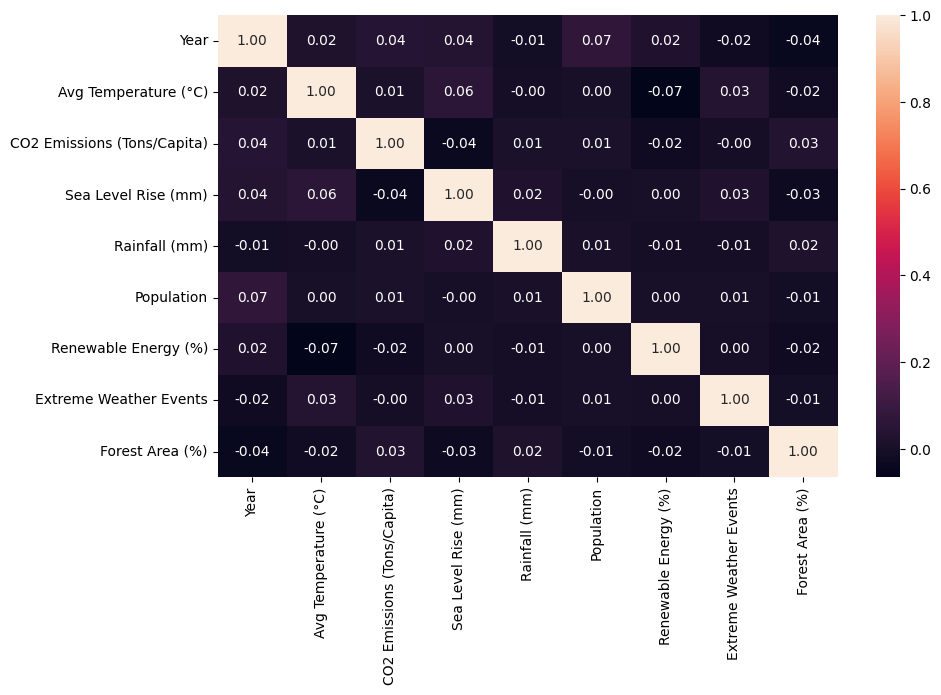

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.show()

Checking for duplicates per country-year

In [ ]:
df.duplicated(subset=['Country','Year']).sum()

np.int64(660)

The dataset has multiple entries for the same country in the same year.

In [ ]:
df = df.sort_values(['Country','Year'])
df.head(10)

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
135,2000,Argentina,16.9,3.9,4.0,2047,564877556,15.5,11,18.4
65,2001,Argentina,33.2,18.2,2.9,2372,1078565697,15.7,1,39.7
228,2001,Argentina,24.8,14.3,2.8,2813,332640493,33.8,12,15.6
623,2001,Argentina,21.5,1.1,4.7,2005,597841637,31.6,2,17.7
934,2001,Argentina,8.4,16.8,2.3,2035,1334032802,12.7,3,19.8
675,2002,Argentina,14.3,16.6,2.6,1325,845772793,26.7,7,58.2
852,2002,Argentina,27.6,13.6,1.6,1056,711474124,11.1,10,23.8
305,2003,Argentina,10.0,16.5,1.3,626,1211429158,21.9,13,17.2
39,2004,Argentina,9.8,2.1,1.5,1290,742981303,15.6,1,40.1
795,2004,Argentina,15.4,8.5,2.0,1416,1114422920,31.8,0,46.9


In [ ]:
df = df.groupby(['Country','Year'], as_index=False).mean()
df.head(10)

,Country,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,Argentina,2000,16.900000,3.900000,4.000000,2047.000000,5.648776e+08,15.500000,11.000000,18.400000
1,Argentina,2001,21.975000,12.600000,3.175000,2306.250000,8.357702e+08,23.450000,4.500000,23.200000
2,Argentina,2002,20.950000,15.100000,2.100000,1190.500000,7.786235e+08,18.900000,8.500000,41.000000
3,Argentina,2003,10.000000,16.500000,1.300000,626.000000,1.211429e+09,21.900000,13.000000,17.200000
4,Argentina,2004,12.600000,5.300000,1.750000,1353.000000,9.287021e+08,23.700000,0.500000,43.500000
5,Argentina,2005,14.283333,9.550000,2.933333,1738.166667,8.664392e+08,21.283333,6.833333,39.866667
6,Argentina,2006,22.750000,12.075000,3.675000,1426.750000,7.595240e+08,34.125000,9.250000,46.875000
7,Argentina,2007,7.700000,19.900000,1.600000,918.000000,2.031142e+08,16.900000,10.000000,58.700000
8,Argentina,2008,20.760000,8.800000,3.200000,1574.800000,9.552821e+08,36.300000,8.200000,36.240000
9,Argentina,2009,17.766667,6.933333,3.483333,1769.333333,7.280251e+08,22.733333,6.666667,46.066667


In [ ]:
df.shape

(340, 10)

In [ ]:
duplicates = df[df.duplicated(subset=['Country','Year'], keep=False)]
duplicates.head()

,Country,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      340 non-null    object 
 1   Year                         340 non-null    int64  
 2   Avg Temperature (°C)         340 non-null    float64
 3   CO2 Emissions (Tons/Capita)  340 non-null    float64
 4   Sea Level Rise (mm)          340 non-null    float64
 5   Rainfall (mm)                340 non-null    float64
 6   Population                   340 non-null    float64
 7   Renewable Energy (%)         340 non-null    float64
 8   Extreme Weather Events       340 non-null    float64
 9   Forest Area (%)              340 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 26.7+ KB


In [ ]:
df.describe()

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
count,340.000000,340.000000,340.000000,340.000000,340.000000,3.400000e+02,340.000000,340.000000,340.000000
mean,2011.558824,19.861542,10.488133,3.028851,1707.655784,6.941327e+08,27.561889,7.346362,40.777978
std,7.022892,5.965105,4.039500,0.801448,505.693303,2.875839e+08,9.154376,2.977942,12.477224
min,2000.000000,5.100000,0.800000,1.100000,557.000000,3.019095e+07,5.650000,0.000000,11.200000
25%,2005.000000,16.150000,7.800000,2.533333,1386.000000,5.121874e+08,21.282500,5.393750,33.996667
50%,2012.000000,19.946429,10.587500,3.016250,1687.000000,7.132284e+08,26.692857,7.450000,40.541667
75%,2018.000000,23.533333,13.000000,3.550000,2044.900000,8.940331e+08,33.225000,9.270833,49.625000
max,2023.000000,34.800000,19.900000,4.900000,2989.000000,1.328982e+09,50.000000,14.000000,68.300000


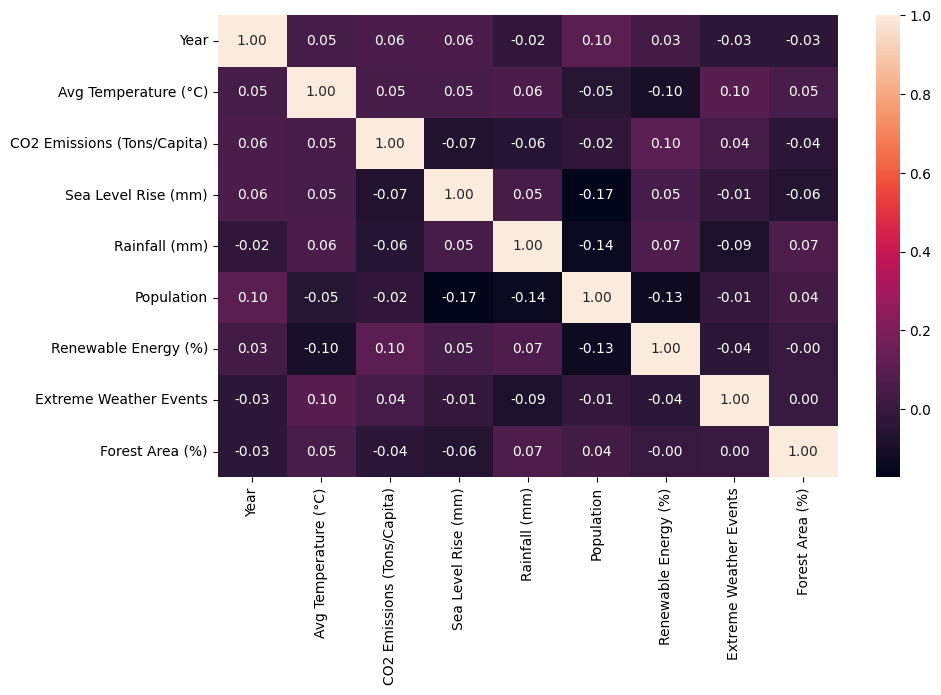

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.show()

Feayure engineering

In [ ]:
# Temperature deviation from global mean
# The difference between a country-year’s average temperature and the global mean temperature across all rows.
# Why it’s useful:
# Highlights which countries are warmer or cooler than the global average
# Useful for visualizing relative warming trends rather than absolute values.
df['Temp_Deviation'] = df['Avg Temperature (°C)'] - df['Avg Temperature (°C)'].mean()

# CO2 Emissions per 1M people
# The total CO2 emissions in millions of tons for a given country-year, calculated from per-capita emissions multiplied by population.
# Why it’s useful:
# Standardizes CO2 contributions by country size.
# Allows fair comparison between small and large countries.
# Useful for visualizations that show total emissions impact, not just per capita.
df['CO2_per_million'] = df['CO2 Emissions (Tons/Capita)'] * df['Population'] / 1_000_000

# Renewable Energy ratio
df['Renewable_Ratio'] = df['Renewable Energy (%)'] / 100

# Categorize countries by forest area
# Categorizes countries based on the percentage of land covered by forests:
# 0–25% → Low forest area
# 25–50% → Medium forest area
# 50–100% → High forest area
# Why it’s useful:
# Turns a numeric variable into a categorical feature for comparison.
# Makes it easier to visualize relationships between forest coverage and other metrics like CO2 emissions, temperature, or extreme weather events.
# Helps in grouping countries in plots and interpreting trends.
df['Forest_Category'] = pd.cut(df['Forest Area (%)'], bins=[0, 25, 50, 100],
                               labels=['Low', 'Medium', 'High'])

In [ ]:
df.head(10)

,Country,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%),Temp_Deviation,CO2_per_million,Renewable_Ratio,Forest_Category
0,Argentina,2000,16.900000,3.900000,4.000000,2047.000000,5.648776e+08,15.500000,11.000000,18.400000,-2.961542,2203.022468,0.155000,Low
1,Argentina,2001,21.975000,12.600000,3.175000,2306.250000,8.357702e+08,23.450000,4.500000,23.200000,2.113458,10530.703981,0.234500,Low
2,Argentina,2002,20.950000,15.100000,2.100000,1190.500000,7.786235e+08,18.900000,8.500000,41.000000,1.088458,11757.214223,0.189000,Medium
3,Argentina,2003,10.000000,16.500000,1.300000,626.000000,1.211429e+09,21.900000,13.000000,17.200000,-9.861542,19988.581107,0.219000,Low
4,Argentina,2004,12.600000,5.300000,1.750000,1353.000000,9.287021e+08,23.700000,0.500000,43.500000,-7.261542,4922.121191,0.237000,Medium
5,Argentina,2005,14.283333,9.550000,2.933333,1738.166667,8.664392e+08,21.283333,6.833333,39.866667,-5.578208,8274.494085,0.212833,Medium
6,Argentina,2006,22.750000,12.075000,3.675000,1426.750000,7.595240e+08,34.125000,9.250000,46.875000,2.888458,9171.252602,0.341250,Medium
7,Argentina,2007,7.700000,19.900000,1.600000,918.000000,2.031142e+08,16.900000,10.000000,58.700000,-12.161542,4041.972421,0.169000,High
8,Argentina,2008,20.760000,8.800000,3.200000,1574.800000,9.552821e+08,36.300000,8.200000,36.240000,0.898458,8406.482181,0.363000,Medium
9,Argentina,2009,17.766667,6.933333,3.483333,1769.333333,7.280251e+08,22.733333,6.666667,46.066667,-2.094875,5047.641005,0.227333,Medium


Adding the longitude and latitude columns to our dataset

In [ ]:
df['Country'].nunique(), df['Country'].unique()

(15,
 array(['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France',
        'Germany', 'India', 'Indonesia', 'Japan', 'Mexico', 'Russia',
        'South Africa', 'UK', 'USA'], dtype=object))

In [ ]:
# from geopy.geocoders import Nominatim
# from geopy.exc import GeocoderTimedOut
# import time

# geolocator = Nominatim(user_agent="climate_analysis")

# def get_lat_lon(country):
#     for attempt in range(3):
#         try:
#             loc = geolocator.geocode(country, timeout=10)
#             if loc:
#                 return pd.Series([loc.latitude, loc.longitude])
#             else:
#                 return pd.Series([None, None])
#         except GeocoderTimedOut:
#             time.sleep(2)
#     return pd.Series([None, None])

In [ ]:
# df[['Latitude', 'Longitude']] = df['Country'].apply(get_lat_lon)

In [ ]:
df.head()

,Country,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%),Temp_Deviation,CO2_per_million,Renewable_Ratio,Forest_Category,Latitude,Longitude
0,Argentina,2000,16.900,3.9,4.000,2047.00,5.648776e+08,15.50,11.0,18.4,-2.961542,2203.022468,0.1550,Low,-34.996496,-64.967282
1,Argentina,2001,21.975,12.6,3.175,2306.25,8.357702e+08,23.45,4.5,23.2,2.113458,10530.703981,0.2345,Low,-34.996496,-64.967282
2,Argentina,2002,20.950,15.1,2.100,1190.50,7.786235e+08,18.90,8.5,41.0,1.088458,11757.214223,0.1890,Medium,-34.996496,-64.967282
3,Argentina,2003,10.000,16.5,1.300,626.00,1.211429e+09,21.90,13.0,17.2,-9.861542,19988.581107,0.2190,Low,-34.996496,-64.967282
4,Argentina,2004,12.600,5.3,1.750,1353.00,9.287021e+08,23.70,0.5,43.5,-7.261542,4922.121191,0.2370,Medium,-34.996496,-64.967282


In [ ]:
# df.to_csv("my_dataset_with_coordinates.csv", index=False)

Visualizing Rainfall and Temperature trends

In [ ]:
import pandas as pd
df = pd.read_csv("/content/my_dataset_with_coordinates.csv")
df.head()

,Country,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%),Temp_Deviation,CO2_per_million,Renewable_Ratio,Forest_Category,Latitude,Longitude
0,Argentina,2000,16.900,3.9,4.000,2047.00,5.648776e+08,15.50,11.0,18.4,-2.961542,2203.022468,0.1550,Low,-34.996496,-64.967282
1,Argentina,2001,21.975,12.6,3.175,2306.25,8.357702e+08,23.45,4.5,23.2,2.113458,10530.703981,0.2345,Low,-34.996496,-64.967282
2,Argentina,2002,20.950,15.1,2.100,1190.50,7.786235e+08,18.90,8.5,41.0,1.088458,11757.214223,0.1890,Medium,-34.996496,-64.967282
3,Argentina,2003,10.000,16.5,1.300,626.00,1.211429e+09,21.90,13.0,17.2,-9.861542,19988.581107,0.2190,Low,-34.996496,-64.967282
4,Argentina,2004,12.600,5.3,1.750,1353.00,9.287021e+08,23.70,0.5,43.5,-7.261542,4922.121191,0.2370,Medium,-34.996496,-64.967282


# Visualizations


## Global vs Country Average Temperatures Trends

In [62]:
import pandas as pd
import plotly.graph_objects as go

# -----------------------------
# 1. Data Preparation
# -----------------------------
countries = df["Country"].unique()
global_data = df.groupby("Year")["Avg Temperature (°C)"].mean()

fig = go.Figure()

# -----------------------------
# 2. Add Traces (Layers)
# -----------------------------

# Layer 1: All Countries (The "Context" - Gray Background)
# We add these first so they sit behind the main lines
for country in countries:
    country_df = df[df["Country"] == country]
    fig.add_trace(go.Scatter(
        x=country_df["Year"],
        y=country_df["Avg Temperature (°C)"],
        mode="lines",
        name=country,
        line=dict(color="lightgray", width=1), # Thin gray lines
        opacity=0.5,
        showlegend=False,  # Hide from legend to keep it clean
        hoverinfo="name+y" # Show country name on hover
    ))

# Layer 2: Global Average (The "Focus" - Bold Trend)
fig.add_trace(go.Scatter(
    x=global_data.index,
    y=global_data.values,
    mode="lines",
    name="Global Average",
    line=dict(color="black", width=4), # Thick black line
    hoverinfo="name+y"
))

# -----------------------------
# 3. Interactive Dropdown for Highlighting
# -----------------------------
# Create a button for each country to highlight it when selected
buttons = []

# "Reset" button (Show only Global Average highlighted)
buttons.append(dict(
    method='update',
    label='Show Global Only',
    args=[{"line.color": ["lightgray"] * len(countries) + ["black"],
           "line.width": [1] * len(countries) + [4],
           "opacity": [0.5] * len(countries) + [1]}]
))

for i, country in enumerate(countries):
    # Create a color list where only the selected country is colored (e.g., Red)
    # The last item is always Black (Global Average)
    colors = ["lightgray"] * len(countries) + ["black"]
    widths = [1] * len(countries) + [4]
    opacities = [0.3] * len(countries) + [1] # Fade others out more
    dashes = ["solid"] * len(countries) + ["solid"]

    # Highlight the specific country
    colors[i] = "green"
    widths[i] = 3
    opacities[i] = 1.0
    dashes[i] = "dot"

    buttons.append(dict(
        method='update',
        label=country,
        args=[{"line.color": colors,
               "line.width": widths,
               "opacity": opacities,
               "line.dash": dashes}]
    ))

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.23, # Position dropdown to the right
        y=1,
        xanchor='left',
        yanchor='top'
    )]
)

# -----------------------------
# 4. Layout & Annotations
# -----------------------------
fig.update_layout(
    title="<b>Global Temperature Trends</b><br><span style='font-size:12px;color:gray'>Comparison of 15 Major Countries against Global Average</span>",
    xaxis_title="Year",
    yaxis_title="Average Temperature (°C)",
    template="plotly_white",
    width=1100, # Slightly wider to accommodate the dropdown
    height=600,
    hovermode="x unified", # Shows all values for a specific year on hover
    margin=dict(r=150) # Extra right margin for the dropdown menu
)

# Annotation for the Global Trend
fig.add_annotation(
    x=global_data.index.max(),
    y=global_data.values[-1],
    text="Global Avg",
    showarrow=False,
    xanchor="left",
    font=dict(color="black", size=12, weight="bold"),
    bgcolor="white"
)

fig.show()

### Analysis of the Line Chart (Focus + Context)
**Purpose:** Shows the overall distribution and range of the data showing Global Stability vs. Local Chaos.

**The Context:** The light gray lines ("spaghetti") represent the noise and range of all 15 countries in the dataset.

**The Baseline:** The thick black line represents the Global Average. It acts as the anchor, showing the central tendency of the data.

**The Focus:** The green dotted line highlights any chosen country. This allows the viewer to instantly compare a specific local trend against the global baseline without getting lost in the clutter of other countries.

**Interpretation of Variance:** The fact that the background lines are so messy (the "spaghetti" effect) reinforces that calculating a "Global Average" might be hiding the reality of what is happening on the ground. A global average of 20°C doesn't mean much to a country experiencing a 34°C heatwave (China) or a 8°C cold snap (Soth Africa) in the same year (2008).

Basically;
**The average doesn't tell the whole story because real weather is messy**
- Some years, one country is freezing (bottom of the chart).
- The same year, another country is boiling (top of the chart).
- Because they are all happening at once, the chart looks chaotic.

In [63]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------------
# 1. Data Prep
# -----------------------------
countries = sorted(df["Country"].unique())
global_data = df.groupby("Year")["Avg Temperature (°C)"].mean()
global_mean_val = df["Avg Temperature (°C)"].mean() # For range setting

# -----------------------------
# 2. Create Grid Layout (5 Rows x 3 Cols)
# -----------------------------
fig = make_subplots(
    rows=5, cols=3,
    subplot_titles=countries, # Titles for each mini-chart
    vertical_spacing=0.08,
    horizontal_spacing=0.05
)

# -----------------------------
# 3. Populate the Grid
# -----------------------------
row_idx = 1
col_idx = 1

for country in countries:
    country_df = df[df["Country"] == country]

    # A. Add Global Trend (Background Context - Gray)
    fig.add_trace(go.Scatter(
        x=global_data.index,
        y=global_data.values,
        mode="lines",
        line=dict(color="#e0e0e0", width=2), # Light gray
        showlegend=False,
        hoverinfo="skip"
    ), row=row_idx, col=col_idx)

    # B. Add Country Trend (Focus - Colored)
    # We color based on whether the country is mostly hot (Red) or cold (Blue)
    avg_temp = country_df["Avg Temperature (°C)"].mean()
    line_color = "#D62828" if avg_temp > global_mean_val else "#0077B6"

    fig.add_trace(go.Scatter(
        x=country_df["Year"],
        y=country_df["Avg Temperature (°C)"],
        mode="lines",
        name=country,
        line=dict(color=line_color, width=2),
        showlegend=False
    ), row=row_idx, col=col_idx)

    # Move to next grid cell
    col_idx += 1
    if col_idx > 3:
        col_idx = 1
        row_idx += 1

# -----------------------------
# 4. Final Polish
# -----------------------------
fig.update_layout(
    title="<b>Global Climate Analysis: Country vs Global Trends</b><br><span style='font-size:12px;color:gray'>Gray Line = Global Average | Red/Blue Line = Country Trend</span>",
    height=1000, # Tall chart to fit everything
    width=1000,
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

### Analysis of Small Multiples (Country vs. Global Trends)
**Purpose:** Compares each country's specific trend (Red/Blue) against the Global Average (Gray).

**Geographic Grouping (Hot vs. Cold):**

The "Hot" Group (Red Lines): Countries like Brazil, India, Indonesia, and Mexico consistently track above the global average. Their volatility is high, often spiking far above the gray line.

The "Cold" Group (Blue Lines): Countries like UK, Russia, Canada, and Germany consistently track below or intertwine with the global average.

**The "Sawtooth" Pattern:**

Almost every country exhibits a jagged, "sawtooth" line shape. This confirms extreme annual instability. For example, look at Russia: it dives deep in one year and spikes high the next. This behavior is very different from the smoother gray global line in the background.

**Lack of Synchronization:**

When the Global Average (gray) rises, the Country lines do not automatically rise with it. For instance, in China, there are years where the gray line is flat, but the red line drops sharply (around 2015). This suggests these countries have independent climate drivers.

In [64]:
import plotly.express as px

# Create a pivot table for the Heatmap: Index=Country, Columns=Year, Values=Temp
heatmap_data = df.pivot(index="Country", columns="Year", values="Avg Temperature (°C)")

fig = px.imshow(
    heatmap_data,
    color_continuous_scale="RdBu_r", # Red-Blue Reverse (Red=Hot, Blue=Cold)
    aspect="auto",
    title="<b>Temperature Anomaly Detection Matrix</b>",
    labels=dict(color="Temp (°C)")
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title="Year",
    yaxis_title="Country"
)

fig.show()

### Temporal Analysis of Temperature Trends (Row-by-Row)
Reading the heatmap matrix horizontally (left-to-right) provides a chronological view of each country's climate history over the 24-year period. This perspective reveals three critical insights regarding the nature of the data:

**Trend Detection: "Gradient" vs. "Barcode" Patterns**

*Expectation:* In a scenario of consistent global warming, we would expect to see a smooth temporal gradient—transitioning from cool colors (blues) in the earlier years (left) to warm colors (reds) in recent years (right).

*Observation:* Instead of a smooth transition, the rows resemble a "barcode" pattern, where colors alternate frequently between warm and cool.

*Insight:* This indicates that short-term oscillations are dominating the dataset. For countries like Germany and France, the lack of a clear left-to-right color shift suggests that annual temperature variability is overpowering any steady, long-term warming trend in this specific time window.

**2. Identification of Temporal Anomalies ("Shock Years")**

*Observation:* Scanning laterally allows us to pinpoint isolated extreme events. For instance, Brazil displays a distinct, isolated block of deep red (approx. 30°C+) around 2005, surrounded by lighter colors.

*Insight:* This visualization confirms that such temperature spikes are transient anomalies (e.g., specific heatwave events) rather than permanent climatic shifts. The matrix allows us to distinguish between a "hot year" and a "hot climate."

**3. Assessment of Inter-Annual Stability**

*Observation:* The frequency of color changes along a row acts as a proxy for climatic stability.

*Insight:*

- High Stability: Rows that maintain a consistent shade indicate a predictable climate with low variance.

- High Volatility: Rows that shift rapidly between contrasting colors (e.g., Russia and Canada jumping from deep blue to deep red) evidence high inter-annual volatility. These nations experience violent shifts in weather patterns from one year to the next, lacking year-over-year consistency.

The data reveals a high degree of volatility and a weak correlation between individual countries and the Global Average. While the Global Average (black/gray line) remains relatively stable between 17°C and 24°C, individual nations experience extreme annual fluctuations, suggesting that local factors or micro-climates are driving temperatures more than a unified global trend in this specific dataset.

## Rate of Temperature Increase (The "Warming Velocity")

In [57]:
import plotly.graph_objects as go
from scipy.stats import linregress
import pandas as pd

# ... (Assuming df and temp_slopes logic is already run) ...
temp_slopes = temp_slopes.sort_values("Temp_Slope", ascending=False)
colors = ['#EF553B' if slope > 0 else '#636EFA' for slope in temp_slopes['Temp_Slope']]

# Identify Key Data Points
fastest_warming = temp_slopes.iloc[0]
fastest_cooling = temp_slopes.iloc[-1]

# Identify Top 2 Most Stable
temp_slopes['Abs_Slope'] = temp_slopes['Temp_Slope'].abs()
stable_countries = temp_slopes.nsmallest(2, 'Abs_Slope')
stable_1 = stable_countries.iloc[0]
stable_2 = stable_countries.iloc[1]

# ---------------------------------------------------------------------------
# PLOTTING
# ---------------------------------------------------------------------------
fig_temp = go.Figure()

fig_temp.add_trace(go.Bar(
    x=temp_slopes["Country"],
    y=temp_slopes["Temp_Slope"],
    marker_color=colors,
    text=[f"{v:.3f}" for v in temp_slopes["Temp_Slope"]],
    textposition="outside",
    name="Temp Trend"
))

# ---------------------------------------------------------------------------
# ANNOTATIONS (FIXED)
# ---------------------------------------------------------------------------

# 1. Fastest Warming (Fixed: Use yshift instead of ay)
fig_temp.add_annotation(
    x=fastest_warming["Country"],
    y=fastest_warming["Temp_Slope"],
    text="<b>Fastest Warming</b>",
    showarrow=False,         # No arrow
    yshift=30,               # <--- FIX: Moves text up 30px from the bar top
    font=dict(color="#333")
)

# 2. Fastest Cooling (Fixed: Use yshift)
fig_temp.add_annotation(
    x=fastest_cooling["Country"],
    y=fastest_cooling["Temp_Slope"],
    text="<b>Fastest Cooling</b>",
    showarrow=False,         # No arrow
    yshift=-30,              # <--- FIX: Moves text down 30px from the bar bottom
    font=dict(color="#333")
)

# 3. Most Stable (Fixed: Separated Text from Arrows for perfect alignment)

# 3. Most Stable (Text Box Only - No Arrows)
fig_temp.add_annotation(
    x=stable_1["Country"],
    y=stable_1["Temp_Slope"],
    text="<b>Most Stable</b><br>with the Least Change<br>over the years",
    showarrow=False,       # No arrows as requested
    xshift=40,             # <--- FIX: Moves text 20px to the right
    yshift=50 if stable_1["Temp_Slope"] > 0 else -50, # Keeps it floating above/below
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor="#333",
    borderwidth=1
)

# ---------------------------------------------------------------------------
# LAYOUT
# ---------------------------------------------------------------------------
y_min = temp_slopes["Temp_Slope"].min()
y_max = temp_slopes["Temp_Slope"].max()

fig_temp.update_layout(
    title="<b>Global Temperature Trends</b><br><i>Sorted by Rate of Change (°C/year)</i>",
    xaxis_title="Country",
    yaxis_title="Temperature Slope (°C/Year)",
    template="plotly_white",
    height=700,
    # Expand Y-axis to fit the floating labels
    yaxis_range=[y_min * 1.3, y_max * 1.4],
    shapes=[dict(type="line", x0=-0.5, x1=len(temp_slopes)-0.5, y0=0, y1=0, line=dict(color="black", width=1))]
)

fig_temp.show()

### Interpretation:
This chart visualizes the linear regression slope of temperature over time. It does not show which country is the hottest; it shows which country is **changing** the fastest.

**The Y-Axis (Rate of Change):** This represents the speed of warming. A value of 0.05 means the average temperature increases by 0.05°C every single year. Over 20 years, that is a full 1°C rise.

**Red Bars (Positive Slope):** These countries are experiencing a warming trend.

**Tallest Red Bar:** This is the "Fastest Warming" country. It is arguably the most vulnerable to rapid climate change, as its ecosystem has the least time to adapt.

**Blue Bars (Negative Slope):** These countries are experiencing a cooling trend.

While the 'Fastest Warming' country highlights the risk of heat, the 'Fastest Cooling' country highlights the risk of erratic weather patterns. **The most resilient countries are those clustered near the zero line, exhibiting the highest degree of climatic stability.** Their climate is consistent, neither warming nor cooling significantly over the analyzed period.

## Rate of Rainfall Change (The "Hydrological Shift")

In [58]:
import plotly.graph_objects as go
from scipy.stats import linregress
import pandas as pd

# ---------------------------------------------------------------------------
# DATA PREPARATION
# ---------------------------------------------------------------------------

# 1. Compute rainfall trend (slope)
rain_slopes = (
    df.groupby("Country")
    .apply(lambda g: linregress(g["Year"], g["Rainfall (mm)"]).slope)
    .reset_index(name="Rain_Slope")
)

# 2. Sort values (Greatest Increase on left, Greatest Decrease on right)
rain_slopes = rain_slopes.sort_values("Rain_Slope", ascending=False)

# 3. Define colors: Teal/Green for wetter (+), Purple/Brown for drier (-)
colors_rain = ['#00CC96' if slope > 0 else '#AB63FA' for slope in rain_slopes['Rain_Slope']]

# 4. Identify Key Data Points
largest_increase = rain_slopes.iloc[0]
largest_decrease = rain_slopes.iloc[-1]

# 5. Identify Most Stable (Closest to 0)
rain_slopes['Abs_Slope'] = rain_slopes['Rain_Slope'].abs()
stable_rain_country = rain_slopes.nsmallest(1, 'Abs_Slope').iloc[0]

# ---------------------------------------------------------------------------
# PLOTTING
# ---------------------------------------------------------------------------
fig_rain = go.Figure()

fig_rain.add_trace(go.Bar(
    x=rain_slopes["Country"],
    y=rain_slopes["Rain_Slope"],
    marker_color=colors_rain,
    text=[f"{v:.1f}" for v in rain_slopes["Rain_Slope"]], # Removed "mm/yr" to keep it clean like temp
    textposition="outside",
    name="Rain Trend"
))

# ---------------------------------------------------------------------------
# ANNOTATIONS (MATCHING TEMP STYLE)
# ---------------------------------------------------------------------------

# 1. Greatest Increase (Top Left)
fig_rain.add_annotation(
    x=largest_increase["Country"],
    y=largest_increase["Rain_Slope"],
    text="<b>Greatest Increase</b>",
    showarrow=False,
    yshift=30,       # Moves text up 30px
    font=dict(color="#333")
)

# 2. Greatest Decrease (Bottom Right)
fig_rain.add_annotation(
    x=largest_decrease["Country"],
    y=largest_decrease["Rain_Slope"],
    text="<b>Greatest Decrease</b>",
    showarrow=False,
    yshift=-30,      # Moves text down 30px
    font=dict(color="#333")
)

# 3. Most Stable (Floating Box)
fig_rain.add_annotation(
    x=stable_rain_country["Country"],
    y=stable_rain_country["Rain_Slope"],
    text="<b>Most Stable</b><br>with the Least Change<br>over the years",
    showarrow=False,
    xshift=-20,       # Moves text 40px to the right
    # If bar is positive, push text up; if negative, push text down
    yshift=50 if stable_rain_country["Rain_Slope"] > 0 else -50,
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor="#333",
    borderwidth=1
)

# ---------------------------------------------------------------------------
# LAYOUT
# ---------------------------------------------------------------------------
y_min = rain_slopes["Rain_Slope"].min()
y_max = rain_slopes["Rain_Slope"].max()

fig_rain.update_layout(
    title="<b>Global Rainfall Trends</b><br><i>(Sorted by Rate of Change mm/year)</i>",
    xaxis_title="Country",
    yaxis_title="Rate of Change (mm/Year)",
    template="plotly_white",
    height=700,
    showlegend=False,
    # Expand Y-axis to fit the floating labels (Same math as Temp chart)
    yaxis_range=[y_min * 1.3, y_max * 1.4],
    shapes=[dict(type="line", x0=-0.5, x1=len(rain_slopes)-0.5, y0=0, y1=0, line=dict(color="black", width=1))]
)

fig_rain.show()

/tmp/ipython-input-3846247131.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### Interpretation:
This chart visualizes shifts in precipitation patterns, indicating risks of either flooding or desertification.

**The Y-Axis (mm/year):**  This shows the volume of water being gained or lost annually.

**Green Bars (Positive Slope):** These countries are getting more rain over time.

**Tallest Green Bar:** This country is seeing the most drastic increase in rainfall. While this can be good for agriculture, an extreme rate often indicates a **higher risk of flooding, storms, and infrastructure damage.**

**Purple Bars (Negative Slope):** These countries are getting drier over time.

**Lowest/Negative Bar:** This indicates a shrinking water supply. This country faces the **highest risk of drought, desertification, and water scarcity.**

The **most resilient countries are those clustered near the zero line**, exhibiting the **highest degree of hydrological stability**. Their precipitation patterns remain consistent, avoiding the dual threats of excess saturation and resource depletion seen at the extremes.

## Global Rainfall Trend Analysis Per Continent (mm/year)

In [76]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go # Needed for the custom text labels
from scipy.stats import linregress

# -------------------------------
# Compute rainfall trend (slope) per country
# -------------------------------
# Assuming 'df' is already loaded with your data
rain_slopes = (
    df.groupby("Country")
      .apply(lambda g: linregress(g["Year"], g["Rainfall (mm)"]).slope)
      .reset_index(name="Rainfall_Slope")
)

# -------------------------------
# 1. Create the Base Map
# -------------------------------
fig_map = px.choropleth(
    rain_slopes,
    locations="Country",
    locationmode="country names",
    color="Rainfall_Slope",
    # CORRECTED SCALE: "RdBu" (No '_r')
    # Now Red = Dry (Low), Blue = Wet (High)
    color_continuous_scale="RdBu",
    title="Global Rainfall Trend by Country (mm per year)",
)

# -------------------------------
# 2. Add Continent Labels
# -------------------------------
# We define approximate center points (lat, lon) for the labels
continent_labels = [
    {"name": "North America", "lat": 50, "lon": -100},
    {"name": "South America", "lat": -15, "lon": -60},
    {"name": "Europe", "lat": 50, "lon": 0},
    {"name": "Africa", "lat": 0, "lon": 20},
    {"name": "Asia", "lat": 45, "lon": 90},
    {"name": "Oceania", "lat": -25, "lon": 135},
]

# extract lists for the scattergeo function
lons = [c["lon"] for c in continent_labels]
lats = [c["lat"] for c in continent_labels]
names = [c["name"] for c in continent_labels]

# Add the labels as a new "trace" on top of the map
fig_map.add_trace(go.Scattergeo(
    lon=lons,
    lat=lats,
    text=names,
    mode="text",
    textfont=dict(
        family="Arial",
        size=14,
        color="black"
    )
))

# -------------------------------
# 3. Final Layout Updates
# -------------------------------
fig_map.update_layout(
    geo=dict(showframe=False, projection_type="natural earth"),
    coloraxis_colorbar=dict(title="Rainfall<br>Slope (mm/year)"),
    width=950,
    height=550,
    showlegend=False # Hides the legend for the text labels (keeps the colorbar)
)

fig_map.show()

/tmp/ipython-input-1158306521.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### Interpretation:
**The Americas: A North-South Climate Divide**

*South America (Getting Significantly Wetter):* This region shows the most intense positive trend globally. Brazil and Argentina exhibit a sharp increase in annual rainfall, suggesting a shift toward wetter climates and potential flood risks.

*North America (Getting Drier):* In sharp contrast, the United States and Mexico show a drying trend (negative slope). Canada differs from its neighbors, showing a mild increase in precipitation.

**Asia: Divergence Between Giants**

*China (Major Drying Trend):* China stands out with a strong negative slope, indicating a significant reduction in annual rainfall.

*India & Southeast Asia (Getting Wetter):* Conversely, India and the Indonesian archipelago are trending positively, likely experiencing heavier monsoons or increased tropical rainfall activity.

**Europe: The Drying Center**

*Central & Western Europe:* Key nations like Germany and France display a negative rainfall slope. This aligns with broader observations of drier summers and water scarcity concerns across the continent.

**Global Pattern: Latitude Matters**

*The "Dry" Mid-Latitudes:* A distinct belt of **drying trends appears across the Northern Hemisphere mid-latitudes**, affecting major agricultural powerhouses in the US, Europe, and China.

*The "Wet" Tropics & South:* **Regions closer to the equator and in the Southern Hemisphere (South America, SE Asia, parts of Australia) are generally seeing intensified rainfall.**

## Scatter Plot (Rainfall vs Temp vs Extreme Weather)

In [83]:
import plotly.graph_objects as go

# ----------------------------------------------
# Compute temperature trend per country
# ----------------------------------------------
temp_slopes = (
    df.groupby("Country")
      .apply(lambda g: linregress(g["Year"], g["Avg Temperature (°C)"]).slope)
      .reset_index(name="Temp_Slope")
)

# ----------------------------------------------
# Compute extreme weather events trend per country
# ----------------------------------------------
weather_slopes = (
    df.groupby("Country")
      .apply(lambda g: linregress(g["Year"], g["Extreme Weather Events"]).slope)
      .reset_index(name="ExtremeEvents_Slope")
)

# Merge all trends
trend_df = (
    rain_slopes
    .merge(temp_slopes, on="Country")
    .merge(weather_slopes, on="Country")
)


fig_scatter = go.Figure()

fig_scatter.add_trace(go.Scatter(
    x=trend_df["Temp_Slope"],
    y=trend_df["Rainfall_Slope"],
    mode="markers+text",
    text=trend_df["Country"],
    textposition="top center",
    marker=dict(
        size=18,                                # constant size
        color=trend_df["ExtremeEvents_Slope"],  # color = weather trend
        colorscale="RdBu_r",
        showscale=True,
        colorbar=dict(title="Extreme Weather<br>Trend (slope)")
    )
))

fig_scatter.update_layout(
    title="Rainfall Trend vs Temperature Trend",
    xaxis_title="Temperature Trend (°C/year)",
    yaxis_title="Rainfall Trend (mm/year)",
    template="plotly_white",
    width=950,
    height=600
)

fig_scatter.show()


/tmp/ipython-input-1986709939.py:8: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipython-input-1986709939.py:17: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### Interpretation
- **X-axis:** Temperature trend
- **Y-axis:** Rainfall trend
- **Bubble color:** Extreme weather trend
- **Positive Weather Trend (+):** The number of bad events is going up every year.
- **Negative Weather Trend (-):** The number of bad events is going down every year.

The visualization reveals a **strong positive correlation between rising temperatures and the frequency of extreme weather events.**

**Rainfall Independence:** Changes in rainfall (Y-axis) appear to have a weaker correlation with extreme weather frequency compared to temperature.

**Key Insight:**
- Canada is the most critical example. It has the highest rate of warming (~0.37°C/year) and one of the highest increases in extreme weather events, despite rainfall remaining relatively stable. This suggests that for Canada, heat is the primary driver of instability.
- France and China are rapidly cooling and drying (negative rainfall trend). This climatic shift coincides with a significant decrease in reported extreme weather events, suggesting a stabilizing effect in these specific regions.

**The Anomalies (Outliers)**
Two countries break the general pattern and require specific attention:

*Argentina:* A fascinating outlier. It is warming moderately (positive X) and experiencing a massive increase in rainfall (+20 mm/year, the highest on the chart). Yet, surprisingly, it shows a sharp decrease in extreme weather events (Dark Blue). This suggests that while Argentina is getting wetter and warmer, these changes are not manifesting as "extreme" instability in this dataset.

*USA:* The USA is warming slightly (+0.05°C/year) but is seeing a decrease in extreme weather events. This contrasts with neighbors like Canada, suggesting that local geographic factors or infrastructure resilience might be mitigating the impact of warming.

**Temperature vs. Extreme Events (X-Axis Correlation):** There is a visible trend where moving from left to right (Cooler $\to$ Warmer) changes the marker color from Blue $\to$ Red. This indicates that Temperature Trend is a reliable predictor of Extreme Weather frequency in this dataset.

**Rainfall vs. Extreme Events (Y-Axis Correlation):** There is no clear vertical pattern. High rainfall countries (Argentina) and low rainfall countries (France) both show decreasing extreme events. This implies that Rainfall trends alone are not a strong predictor of extreme weather frequency.

## Final Conclusion: The Illusion of Global Stability
**1. The Core Finding:** Global Averages Mask Local Chaos
The most critical takeaway from this analysis is that Global Average Temperature is a misleading metric for assessing risk.

*The Illusion:* While the global baseline (the black line) appears smooth and stable between 17°C and 24°C, it hides the violent reality on the ground.

*The Reality:* The "Sawtooth Pattern" observed in individual country lines reveals that local climates are volatile. A nation like Russia or Canada can experience extreme heat one year and a cold snap the next, irrespective of the global trend.

*Verdict:* We are not witnessing a uniform global warming, but rather localized destabilization.

**2. The Drivers of Instability:** Heat is the Trigger
Our scatter plot analysis provided the "smoking gun" regarding what drives extreme weather events:

*Temperature is the Primary Driver:* There is a strong positive correlation between rapid warming and the rise of extreme weather events. Countries moving furthest right on the X-axis (warming fastest) are turning Red (more disasters).

*Rainfall is Secondary:* While rainfall trends vary wildly—from the "Drying Mid-Latitudes" (USA, China, Europe) to the "Soaking South" (Argentina, Brazil)—rainfall volume alone does not predict disaster frequency as reliably as heat does.

**3. Regional Risk Profiles**
Based on the intersection of Temperature, Rainfall, and Extreme Events, we can categorize nations into three distinct risk profiles:

*High-Volatility Zone (The "Hot Spots"):* Canada, Russia, Indonesia.

The Risk: These nations are warming the fastest and show the sharpest increase in extreme weather events. Canada is the primary concern, with the highest warming rate (~0.37°C/year) correlating directly with increased instability.

*Resource Scarcity Zone (The "Drying Belt"):* China, USA, France, Germany.

The Risk: These major agricultural powers are seeing significant negative rainfall trends. While they are currently reporting fewer "extreme events" (storms), their risk is silent: long-term drought, desertification, and water security.

*The Resilience Anomaly: Argentina.*

The Insight: Argentina represents a unique case study. Despite warming moderately and experiencing the world's highest increase in rainfall (+20mm/year), it reports a decrease in extreme weather events. This suggests a transition to a wetter, tropical climate that is not yet manifesting as violent instability.

## Strategic Recommendations
**1. Abandon "One-Size-Fits-All" Policy:** Stakeholders must stop using global averages to allocate resources. A stable global year can still contain a catastrophic heatwave in China or a flood in Brazil. Funding and disaster relief must be allocated based on local volatility metrics (the "Sawtooth" variance) rather than mean temperature.

**2. Prioritize Heat Adaptation for the "Hot Zone":** Immediate infrastructure investment is required for Canada and Russia. Their infrastructure was built for the cold, but their climate is shifting rapidly toward heat and volatility. They face the highest immediate risk of infrastructure failure due to extreme events.

**3. Water Security Strategy for the "Drying Belt":** The USA, China, and Western Europe must pivot focus from "storm defense" to "water retention." The data shows their primary threat is not too much violent weather, but the slow, creeping loss of water resources (Negative Rainfall Slope).

**4. Investigate the "Argentina Model":** Further research is required to understand Argentina's resilience. Is their infrastructure better at handling excess water? Or is the nature of their rainfall (gentle soak vs. flash flood) protecting them? Understanding this anomaly could provide keys to climate adaptation for other nations getting wetter.